# Backteting bt
- https://github.com/pmorissette/bt
- https://pmorissette.github.io/bt/examples.html#buy-and-hold-strategy|

In [3]:
#!pip install bt

In [5]:
import bt

In [6]:
# fetch some data
data = bt.get('sbin.ns', start='2020-01-01')
print(data.tail())

[*********************100%***********************]  1 of 1 completed

                sbinns
Date                  
2025-12-24  968.950012
2025-12-25  968.950012
2025-12-26  966.299988
2025-12-29  965.049988
2025-12-30  969.349976


In [7]:
# create the strategy
s = bt.Strategy('s1', [bt.algos.RunMonthly(),
                       bt.algos.SelectAll(),
                       bt.algos.WeighEqually(),
                       bt.algos.Rebalance()])

In [9]:
# create a backtest and run it
test = bt.Backtest(s, data)
res = bt.run(test)

100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 15.67it/s]


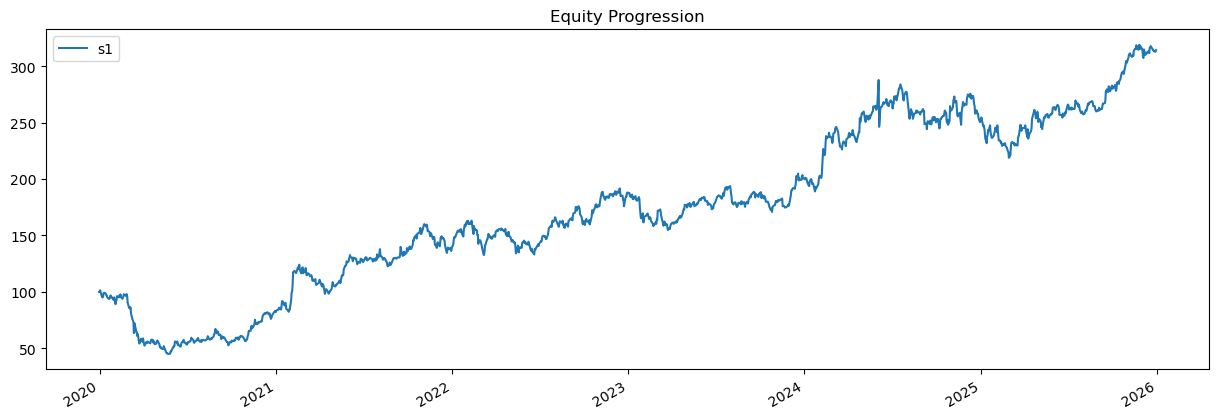

In [10]:
# first let's see an equity curve
res.plot();

In [11]:
# ok and what about some stats?
res.display()

Stat                 s1
-------------------  ----------
Start                2019-12-31
End                  2025-12-30
Risk-free rate       0.00%

Total Return         214.08%
Daily Sharpe         0.78
Daily Sortino        1.25
CAGR                 21.02%
Max Drawdown         -55.53%
Calmar Ratio         0.38

MTD                  -0.99%
3m                   11.11%
6m                   18.16%
YTD                  24.39%
1Y                   25.43%
3Y (ann.)            18.64%
5Y (ann.)            30.56%
10Y (ann.)           -
Since Incep. (ann.)  21.02%

Daily Sharpe         0.78
Daily Sortino        1.25
Daily Mean (ann.)    24.22%
Daily Vol (ann.)     31.02%
Daily Skew           -0.34
Daily Kurt           8.46
Best Day             13.83%
Worst Day            -14.40%

Monthly Sharpe       0.72
Monthly Sortino      1.38
Monthly Mean (ann.)  25.14%
Monthly Vol (ann.)   34.70%
Monthly Skew         0.23
Monthly Kurt         4.03
Best Month           38.30%
Worst Month          -35.03%

Ye

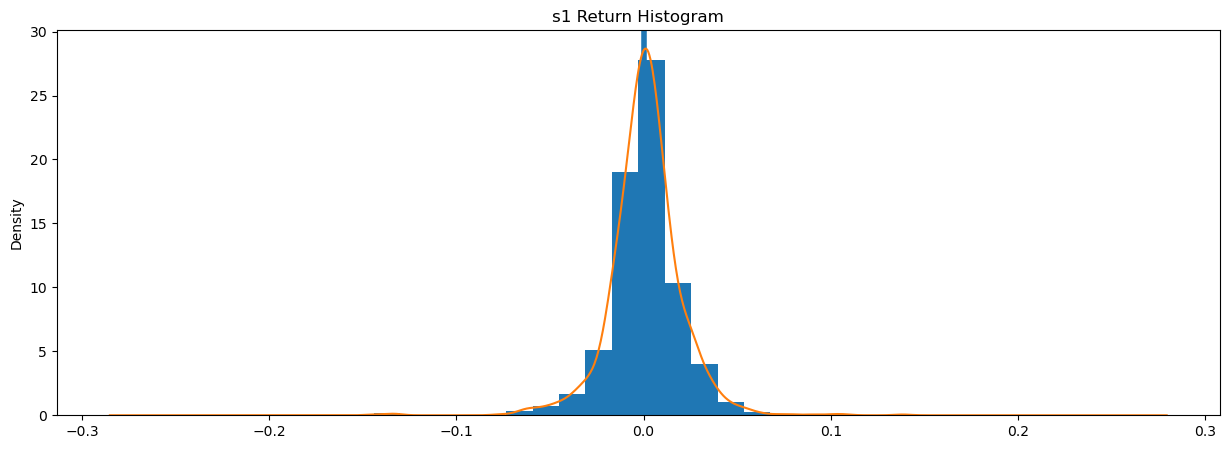

In [12]:
# ok and how does the return distribution look like?
res.plot_histogram()

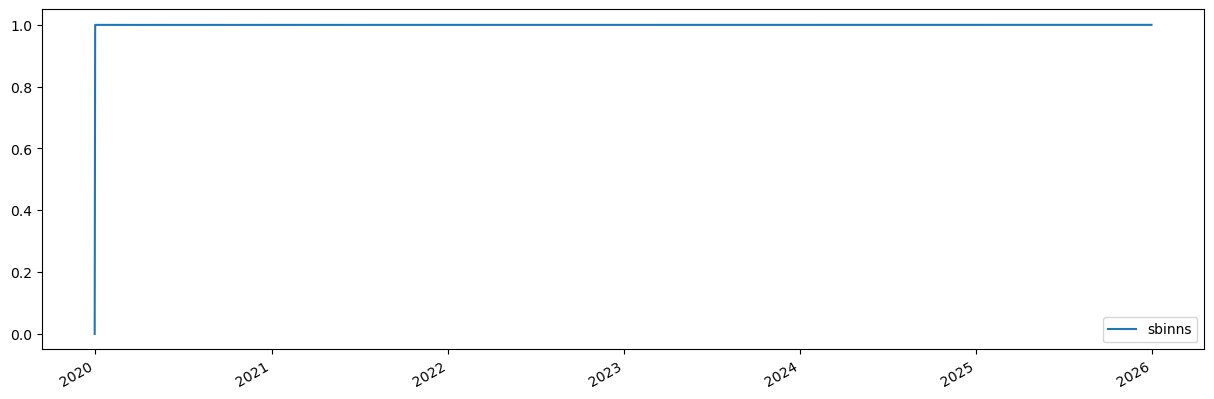

In [13]:
# and just to make sure everything went along as planned, let's plot the security weights over time
res.plot_security_weights()

# Modify Strategy

100%|█████████████████████████████████████████████| 2/2 [00:00<00:00, 18.64it/s]


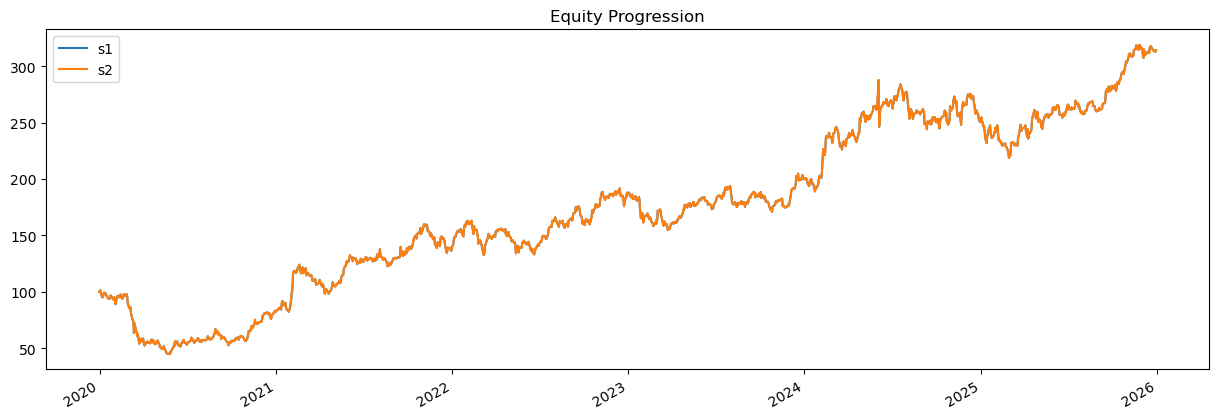

In [14]:
# create our new strategy
s2 = bt.Strategy('s2', [bt.algos.RunWeekly(),
                        bt.algos.SelectAll(),
                        bt.algos.WeighInvVol(),
                        bt.algos.Rebalance()])

# now let's test it with the same data set. We will also compare it with our first backtest.
test2 = bt.Backtest(s2, data)
# we include test here to see the results side-by-side
res2 = bt.run(test, test2)

res2.plot();

In [15]:
res2.display()

Stat                 s1          s2
-------------------  ----------  ----------
Start                2019-12-31  2019-12-31
End                  2025-12-30  2025-12-30
Risk-free rate       0.00%       0.00%

Total Return         214.08%     214.08%
Daily Sharpe         0.78        0.78
Daily Sortino        1.25        1.25
CAGR                 21.02%      21.02%
Max Drawdown         -55.53%     -55.53%
Calmar Ratio         0.38        0.38

MTD                  -0.99%      -0.99%
3m                   11.11%      11.11%
6m                   18.16%      18.16%
YTD                  24.39%      24.39%
1Y                   25.43%      25.43%
3Y (ann.)            18.64%      18.64%
5Y (ann.)            30.56%      30.56%
10Y (ann.)           -           -
Since Incep. (ann.)  21.02%      21.02%

Daily Sharpe         0.78        0.78
Daily Sortino        1.25        1.25
Daily Mean (ann.)    24.22%      24.22%
Daily Vol (ann.)     31.02%      31.02%
Daily Skew           -0.34       -0.34
Dail